In [1]:
import os
import glob
import re

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad

import readfcs
import matplotlib.pyplot as plt

In [1]:


# ============================================================
# 1️⃣ 读取单个 FCS
# ============================================================
def read_fcs(file):

    adata = readfcs.read(
        file,
        reindex=False
    )

    # 转成 Series
    fallback = pd.Series(
        adata.var_names,
        index=adata.var.index
    )

    # 使用 marker
    channel_names = (
        adata.var["marker"]
        .fillna(fallback)
        .astype(str)
        .str.strip()
    )

    df = pd.DataFrame(
        adata.X,
        columns=channel_names.values
    )

    return df

# ============================================================
# 2️⃣ 收集所有 FCS
# ============================================================

base_dir = "/public/users/xueyupeng/VZV/lvzhu/data"

fcs_files = glob.glob(
    os.path.join(base_dir, "*", "separate", "*.fcs")
)

print("Total FCS:", len(fcs_files))



# ============================================================
# 3️⃣ 读取并合并
# ============================================================

dfs = []

for f in fcs_files:

    try:

        df = read_fcs(f)

        sample_id = os.path.basename(f).replace(".fcs", "")

        df["sample_id"] = sample_id

        dfs.append(df)

        print("Loaded:", sample_id)

    except Exception as e:

        print("Failed:", f, e)


df_all = pd.concat(dfs, axis=0, ignore_index=True)

print(df_all.shape)

Total FCS: 200
Loaded: A071-V9_20260323-5_4-3
Loaded: A080-V8_20260323-5_7-3
Loaded: A041-V6_20260323-3_1-3
Loaded: A029-V8_20260323-2_3-3
Loaded: A055-V6_20260323-4_1-3
Loaded: A034-V7_20260323-2_6-3
Loaded: A071-V8_20260323-5_3-3
Loaded: A041-V8_20260323-3_3-3
Loaded: A071-V6_20260323-5_1-3
Loaded: A080-V7_20260323-5_6-3
Loaded: A055-V8_20260323-4_3-3
Loaded: A049-V6_20260323-3_5-3
Loaded: A057-V9_20260323-4_8-3
Loaded: A071-V7_20260323-5_2-3
Loaded: A034-V9_20260323-2_8-3
Loaded: A021-V8_20260323-1_3-3
Loaded: A049-V7_20260323-3_6-3
Loaded: A029-V7_20260323-2_2-3
Loaded: A029-V9_20260323-2_4-3
Loaded: A049-V8_20260323-3_7-3
Loaded: A027-V9_20260323-1_8-3
Loaded: A055-V7_20260323-4_2-3
Loaded: A055-V9_20260323-4_4-3
Loaded: A049-V9_20260323-3_8-3
Loaded: A080-V6_20260323-5_5-3
Loaded: A057-V8_20260323-4_7-3
Loaded: A021-V9_20260323-1_4-3
Loaded: A021-V6_20260323-1_1-3
Loaded: A021-V7_20260323-1_2-3
Loaded: A034-V8_20260323-2_7-3
Loaded: A041-V9_20260323-3_4-3
Loaded: A034-V6_20260323

In [2]:
# ============================================================
# 4️⃣ 构建 AnnData
# ============================================================

feature_cols = [
    c for c in df_all.columns
    if c != "sample_id"
]

X = df_all[feature_cols].values

obs = pd.DataFrame(
    index=[f"cell_{i}" for i in range(df_all.shape[0])]
)

obs["sample_id"] = df_all["sample_id"].values

var = pd.DataFrame(index=feature_cols)

adata = ad.AnnData(
    X=X,
    obs=obs,
    var=var
)



# ============================================================
# 5️⃣ arcsinh transform
# ============================================================

adata.X = np.arcsinh(adata.X / 5)

In [3]:
feature_cols = [
    c for c in df_all.columns
    if c != "sample_id"
]

print("Number of channels:", len(feature_cols))

# 查看通道名
print(feature_cols)

Number of channels: 52
['CD45-1_106Cd', 'CD45-2_110Cd', 'CD45-3_111Cd', 'CD8_112Cd', 'CD3_113In', 'CD45-4_114Cd', 'CD4_115In', 'CD45-5_116Cd', 'CD57_139La', 'CD56_141Pr', 'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm', 'H3K27ac_148Nd', 'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu', 'CCR2_152Sm', 'TNF-a_153Eu', 'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd', 'TCR-gd_158Gd', 'CD38_159Tb', 'CD27_160Gd', 'CD123_161Dy', 'Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 'IL-6_165Ho', 'MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 'CD45RA_170Er', 'HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb', 'pSTAT1_175Lu', 'pSTAT3_176Yb', 'DNA1_191Ir', 'DNA2_193Ir', 'LIVE_198Pt', 'CD16_209Bi', 'CSR', 'Center', 'Event_Length', 'Offset', 'Residual', 'Time']


In [4]:
adata.obs

,sample_id
cell_0,A071-V9_20260323-5_4-3
cell_1,A071-V9_20260323-5_4-3
cell_2,A071-V9_20260323-5_4-3
cell_3,A071-V9_20260323-5_4-3
cell_4,A071-V9_20260323-5_4-3
...,...
cell_58070976,A030-V4_20260312-3_8-3
cell_58070977,A030-V4_20260312-3_8-3
cell_58070978,A030-V4_20260312-3_8-3
cell_58070979,A030-V4_20260312-3_8-3


In [5]:
import re
import pandas as pd


# ============================================================
# sample_id 示例
# A071-V9_20260323-5_4-3
#
# Group        = A
# Participant  = A071
# Timepoint    = V9
# Exp_id       = 20260323
# Exp_position = 5_4
# replicate    = 3
# ============================================================


# ============================================================
# 处理 metadata
# ============================================================

def add_metadata(adata):

    # ========================================================
    # sample_id
    # ========================================================

    if "sample_id" not in adata.obs.columns:
        raise ValueError("adata.obs 中缺少 sample_id")

    sid = adata.obs["sample_id"].astype(str)

    # 去掉 _raw
    sid = sid.str.replace("_raw", "", regex=False)

    adata.obs["sample_id"] = sid

    # ========================================================
    # regex 解析
    # ========================================================
    #
    # A071-V9_20260323-5_4-3
    #
    # group1 = A071
    # group2 = V9
    # group3 = 20260323
    # group4 = 5_4
    # group5 = 3
    #
    # ========================================================

    pattern = r"^([A-Z]\d+)-([Vv]\d+)_([0-9]+)-([0-9]+_[0-9]+)-([0-9]+)$"

    parsed = sid.str.extract(pattern)

    parsed.columns = [
        "Participant",
        "Timepoint",
        "Exp_id",
        "Exp_position",
        "Replicate"
    ]

    # ========================================================
    # Group
    # ========================================================

    parsed["Group"] = (
        parsed["Participant"]
        .str[0]
    )

    # ========================================================
    # 写入 obs
    # ========================================================

    for col in parsed.columns:

        adata.obs[col] = parsed[col].values

    # ========================================================
    # 删除失败样本
    # ========================================================

    bad = adata.obs["Participant"].isna()

    if bad.sum() > 0:

        print(f"WARNING: {bad.sum()} cells failed metadata parsing")

    # ========================================================
    # Timepoint_V
    # ========================================================

    def map_timepoint(row):

        grp = row["Group"]
        tp = row["Timepoint"]

        # ====================================================
        # G
        # ====================================================

        if grp == "G":

            mapping = {
                "V1": "V1Day0",
                "V2": "V1Day1",
            }

            return mapping.get(tp)

        # ====================================================
        # L
        # ====================================================

        elif grp == "L":

            mapping = {
                "V0": "V1Day0",
                "V1": "V1Day1",
                "V5": "V2Day0",
                "V6": "V2Day1",
            }

            return mapping.get(tp)

        # ====================================================
        # A
        # ====================================================

        elif grp == "A":

            mapping = {
                "V0": "V1Day0",
                "V1": "V1Day1",
                "V3": "V2Day0",
                "V4": "V2Day1",

                "V6": "V1Day0",
                "V7": "V1Day1",
                "V8": "V2Day0",
                "V9": "V2Day1",
            }

            return mapping.get(tp)

        return None

    adata.obs["Timepoint_V"] = (
        adata.obs.apply(map_timepoint, axis=1)
    )

    # ========================================================
    # GT
    # ========================================================

    adata.obs["GT"] = (
        adata.obs["Group"].astype(str)
        + "_"
        + adata.obs["Timepoint_V"].astype(str)
    )

    # ========================================================
    # category
    # ========================================================

    categorical_cols = [
        "Group",
        "Participant",
        "Timepoint",
        "Timepoint_V",
        "GT",
        "Exp_id",
        "Exp_position"
    ]

    for c in categorical_cols:

        adata.obs[c] = (
            adata.obs[c]
            .astype("category")
        )

    # ========================================================
    # 输出
    # ========================================================

    print("Metadata parsing finished")
    print()

    print("Group:")
    print(adata.obs["Group"].value_counts())

    print()

    print("Timepoint_V:")
    print(adata.obs["Timepoint_V"].value_counts())

    return adata

In [6]:
adata = add_metadata(adata)

Metadata parsing finished

Group:
Group
A    58070981
Name: count, dtype: int64

Timepoint_V:
Timepoint_V
V2Day1    15285523
V2Day0    14871208
V1Day0    14686536
V1Day1    13227714
Name: count, dtype: int64


In [7]:
adata.obs

,sample_id,Participant,Timepoint,Exp_id,Exp_position,Replicate,Group,Timepoint_V,GT
cell_0,A071-V9_20260323-5_4-3,A071,V9,20260323,5_4,3,A,V2Day1,A_V2Day1
cell_1,A071-V9_20260323-5_4-3,A071,V9,20260323,5_4,3,A,V2Day1,A_V2Day1
cell_2,A071-V9_20260323-5_4-3,A071,V9,20260323,5_4,3,A,V2Day1,A_V2Day1
cell_3,A071-V9_20260323-5_4-3,A071,V9,20260323,5_4,3,A,V2Day1,A_V2Day1
cell_4,A071-V9_20260323-5_4-3,A071,V9,20260323,5_4,3,A,V2Day1,A_V2Day1
...,...,...,...,...,...,...,...,...,...
cell_58070976,A030-V4_20260312-3_8-3,A030,V4,20260312,3_8,3,A,V2Day1,A_V2Day1
cell_58070977,A030-V4_20260312-3_8-3,A030,V4,20260312,3_8,3,A,V2Day1,A_V2Day1
cell_58070978,A030-V4_20260312-3_8-3,A030,V4,20260312,3_8,3,A,V2Day1,A_V2Day1
cell_58070979,A030-V4_20260312-3_8-3,A030,V4,20260312,3_8,3,A,V2Day1,A_V2Day1


In [8]:
import numpy as np
import scanpy as sc

# ============================================================
# 每个 sample_id 随机抽取 1000 个细胞
# ============================================================

np.random.seed(42)

cells_per_sample = 1000

sampled_idx = []

for sid in adata.obs["sample_id"].unique():

    idx = np.where(
        adata.obs["sample_id"] == sid
    )[0]

    # 如果细胞数不足 1000，就全保留
    n_take = min(cells_per_sample, len(idx))

    sampled = np.random.choice(
        idx,
        size=n_take,
        replace=False
    )

    sampled_idx.extend(sampled)

# ============================================================
# subset
# ============================================================

adata_sub = adata[sampled_idx].copy()

print(adata_sub)

AnnData object with n_obs × n_vars = 200000 × 52
    obs: 'sample_id', 'Participant', 'Timepoint', 'Exp_id', 'Exp_position', 'Replicate', 'Group', 'Timepoint_V', 'GT'


In [9]:
markers = ['CD8_112Cd','CD3_113In',  'CD4_115In', 'CD57_139La', 'CD56_141Pr', 
           'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
           'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
           'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd','TCR-gd_158Gd', 'CD38_159Tb', 
           'CD27_160Gd', 'CD123_161Dy','Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 
           'IL-6_165Ho','MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 
           'CD45RA_170Er','HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb',
       'pSTAT1_175Lu', 'pSTAT3_176Yb',  'CD16_209Bi']
mask = adata_sub.var_names.isin(markers)

In [10]:
# ============================================================
# 7️⃣ UMAP
# ============================================================

sc.tl.pca(
    adata_sub,
    n_comps=30,
    mask_var=mask
)

sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=10)

sc.tl.umap(adata_sub)

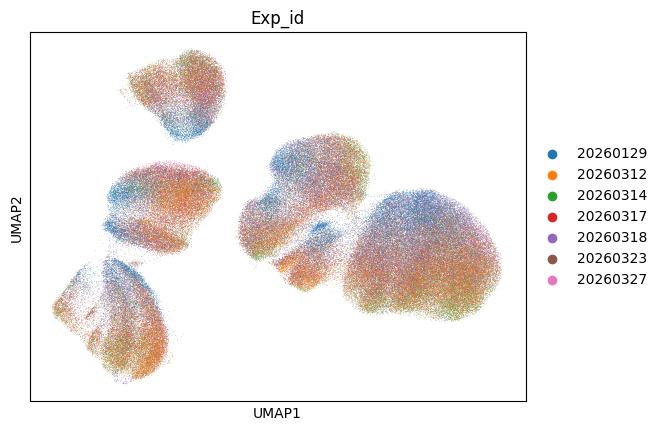

In [11]:
# ============================================================
# 8️⃣ 基础 UMAP
# ============================================================

sc.pl.umap(
    adata_sub,
    color=['Exp_id'],
    wspace=0.4
)

In [13]:
adata.write_h5ad("/public/users/xueyupeng/VZV/cytof/mid_data/full_fcs_combined.h5ad")

In [14]:
adata_sub.write_h5ad("/public/users/xueyupeng/VZV/cytof/mid_data/full_fcs_combined_sub.h5ad")

In [2]:
adata_sub = sc.read_h5ad("/public/users/xueyupeng/VZV/cytof/mid_data/full_fcs_combined_sub.h5ad")

In [6]:
markers = ['CD8_112Cd','CD3_113In',  'CD4_115In', 'CD57_139La', 'CD56_141Pr', 
           'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
           'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
           'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd','TCR-gd_158Gd', 'CD38_159Tb', 
           'CD27_160Gd', 'CD123_161Dy','Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 
           'IL-6_165Ho','MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 
           'CD45RA_170Er','HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb',
       'pSTAT1_175Lu', 'pSTAT3_176Yb',  'CD16_209Bi']
mask = adata_sub.var_names.isin(markers)

In [7]:
import bbknn
sc.tl.pca(
    adata_sub,
    n_comps=30,
    mask_var=mask
)

bbknn.bbknn(
    adata_sub,
    batch_key="Exp_id",
    n_pcs=30,
    neighbors_within_batch=3
)

sc.tl.umap(adata_sub)

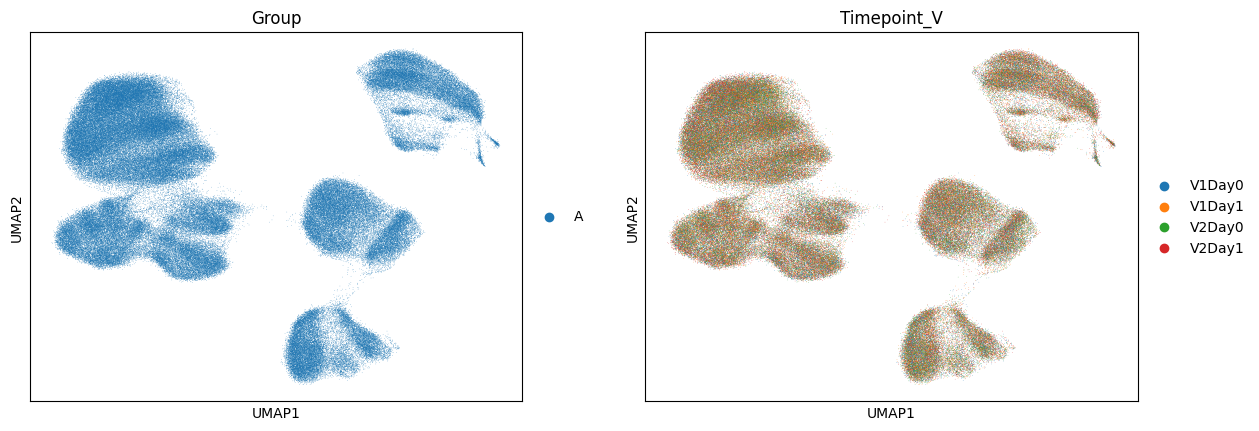

In [8]:
sc.pl.umap(
    adata_sub,
    color=["Group", "Timepoint_V"]
)

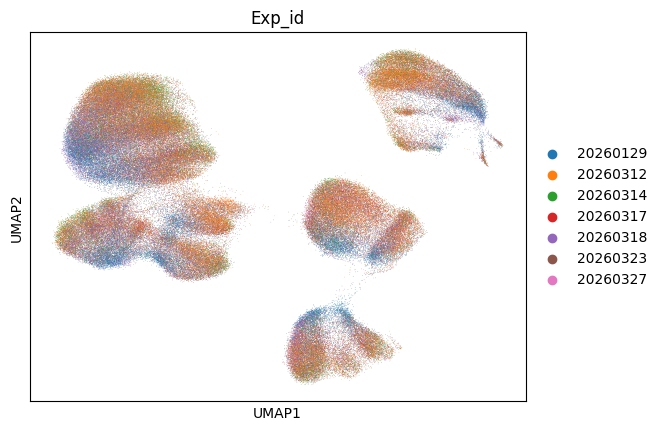

In [9]:
sc.pl.umap(
    adata_sub,
    color=["Exp_id"]
)

In [19]:
# ============================================================
# 4️⃣ 时间顺序
# ============================================================

time_order = [
    "V1Day0",
    "V1Day1",
    "V2Day0",
    "V2Day1"
]

# ============================================================
# 5️⃣ UMAP dataframe
# ============================================================

umap = pd.DataFrame(
    adata_sub.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=adata_sub.obs_names
)

plot_df = pd.concat(
    [umap, adata_sub.obs],
    axis=1
)

In [21]:
# ============================================================
# 6️⃣ 计算 centroid
# ============================================================

centroids = []

for tp in time_order:

    sub = plot_df[
        plot_df["Timepoint_V"] == tp
    ]

    if len(sub) == 0:
        continue

    centroids.append({
        "Timepoint_V": tp,
        "UMAP1": sub["UMAP1"].mean(),
        "UMAP2": sub["UMAP2"].mean()
    })

centroids = pd.DataFrame(centroids)

print(centroids)

  Timepoint_V     UMAP1      UMAP2
0      V1Day0  3.275684  -1.924005
1      V1Day1 -3.246716   6.539032
2      V2Day0  3.481810  10.768654
3      V2Day1 -0.322487  17.357903


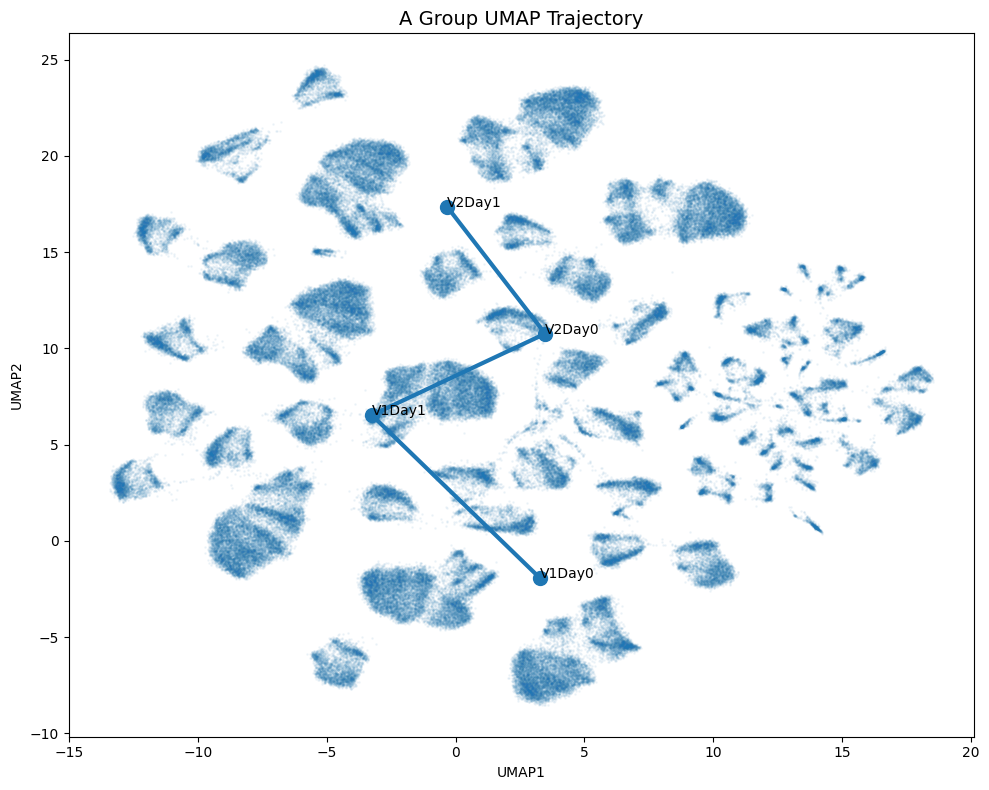

In [23]:
# ============================================================
# 7️⃣ 绘图
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# ------------------------------------------------------------
# 背景细胞
# ------------------------------------------------------------

ax.scatter(
    plot_df["UMAP1"],
    plot_df["UMAP2"],
    s=1,
    alpha=0.05
)

# ------------------------------------------------------------
# trajectory
# ------------------------------------------------------------

centroids = centroids.set_index(
    "Timepoint_V"
).loc[
    [x for x in time_order if x in centroids["Timepoint_V"].values]
].reset_index()

ax.plot(
    centroids["UMAP1"],
    centroids["UMAP2"],
    marker="o",
    linewidth=3,
    markersize=10
)

# ------------------------------------------------------------
# 标注时间点
# ------------------------------------------------------------

for _, row in centroids.iterrows():

    ax.text(
        row["UMAP1"],
        row["UMAP2"],
        row["Timepoint_V"],
        fontsize=10
    )

# ============================================================
# 美化
# ============================================================

ax.set_title(
    "A Group UMAP Trajectory",
    fontsize=14
)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

plt.tight_layout()

# ============================================================
# 保存
# ============================================================

plt.savefig(
    "/public/users/xueyupeng/VZV/lvzhu/plot/celltype_time_boxplot/A_group_UMAP_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()